#### Exercício 1 - Um multiplicador


Ex1 - Resposta impulsiva: [4 0 0 0 0]


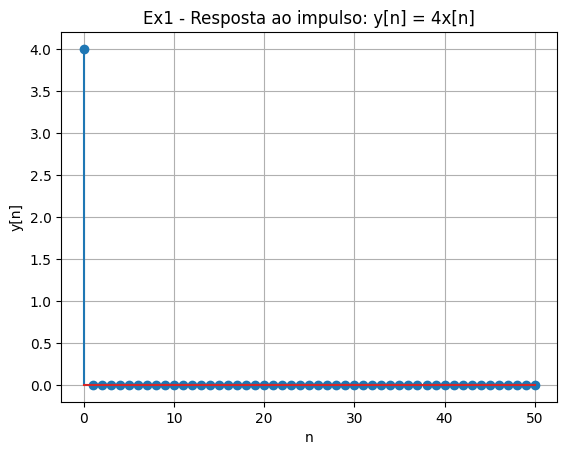

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# (a) Dado o filtro: y[n] = 4x[n]
# Calcule as 5 primeiras amostras da resposta impulsiva (x[n] = δ[n])
n = np.arange(0, 5)
x = np.zeros_like(n)
x[0] = 1  # impulso unitário
y = 4 * x
print("Ex1 - Resposta impulsiva:", y)

# (e) Faça 0 ≤ n ≤ 50 e obtenha um gráfico de y[n]
n_full = np.arange(0, 51)
x_full = np.zeros_like(n_full)
x_full[0] = 1
y_full = 4 * x_full

plt.stem(n_full, y_full)
plt.title('Ex1 - Resposta ao impulso: y[n] = 4x[n]')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid(True)
plt.show()

# É um filtro FIR (resposta impulsiva finita)


#### Exercício 2 - Um filtro FIR

Ex2 - Resposta impulsiva: [ 1.  -0.5  0.7  0.   0. ]


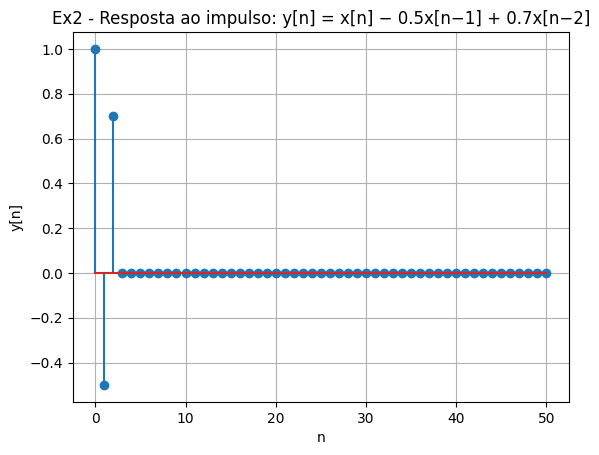

In [4]:
# (a) Dado o filtro: y[n]= x[n] − 0.5x[n−1] + 0.7x[n−2]
# Calcule as 5 primeiras amostras da resposta impulsiva (x[n] = δ[n])
x = np.zeros(5)
x[0] = 1
y = np.zeros(5)

for n in range(5):
    y[n] = x[n] - 0.5*x[n-1] + 0.7*x[n-2] if n >= 2 else (x[n] - 0.5*x[n-1] if n == 1 else x[n])
print("Ex2 - Resposta impulsiva:", y)

# (e) Faça 0 ≤ n ≤ 50 e obtenha um gráfico de y[n]
x_full = np.zeros(51)
x_full[0] = 1
y_full = np.zeros(51)

for n in range(51):
    y_full[n] = x_full[n] - 0.5*x_full[n-1] + 0.7*x_full[n-2] if n >= 2 else (x_full[n] - 0.5*x_full[n-1] if n == 1 else x_full[n])

plt.stem(np.arange(51), y_full)
plt.title('Ex2 - Resposta ao impulso: y[n] = x[n] − 0.5x[n−1] + 0.7x[n−2]')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid(True)
plt.show()

# É um filtro FIR (resposta impulsiva finita)


#### Exercício 3 - Um filtro IIR

Ex3 - Resposta impulsiva: [0.4   0.2   0.1   0.05  0.025]


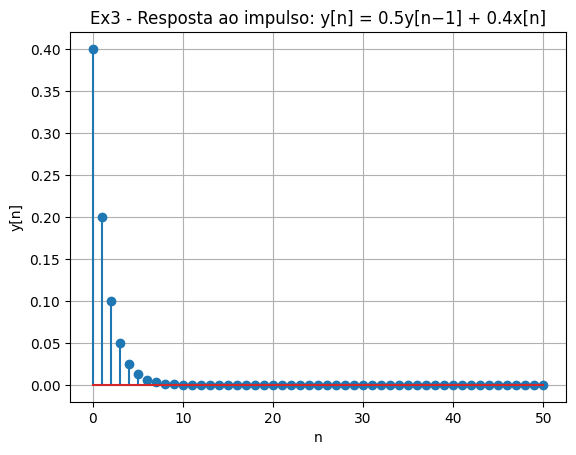

In [8]:
# (a) Dado o filtro: y[n] = 0.5y[n−1] + 0.4x[n], com y[-1] = 0
# Calcule as 5 primeiras amostras da resposta impulsiva (x[n] = δ[n])
x = np.zeros(5)
x[0] = 1
y = np.zeros(5)
y_prev = 0

for n in range(5):
    y[n] = 0.5*y_prev + 0.4*x[n]
    y_prev = y[n]
print("Ex3 - Resposta impulsiva:", y)

# (e) Faça 0 ≤ n ≤ 50 e obtenha um gráfico de y[n]
x_full = np.zeros(51)
x_full[0] = 1
y_full = np.zeros(51)
y_prev = 0

for n in range(51):
    y_full[n] = 0.5*y_prev + 0.4*x_full[n]
    y_prev = y_full[n]

plt.stem(np.arange(51), y_full)
plt.title('Ex3 - Resposta ao impulso: y[n] = 0.5y[n−1] + 0.4x[n]')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid(True)
plt.show()

# É um filtro IIR (resposta impulsiva infinita)


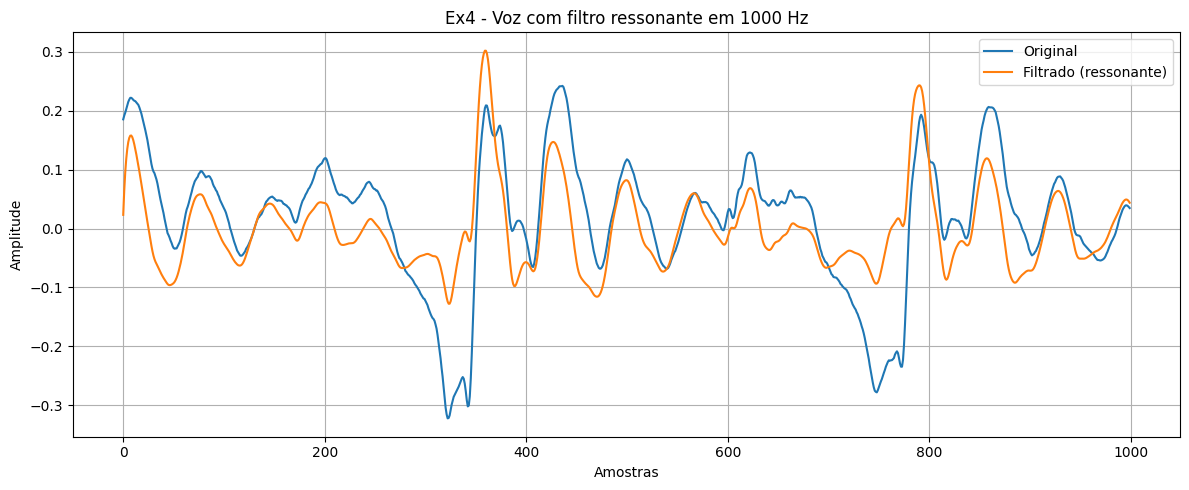

'voz_ressonante.wav'

In [6]:
from scipy.signal import iirpeak
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Carregar o arquivo de áudio enviado
voz_path = "Voz.wav"
sample_rate, audio = wav.read(voz_path)

# Se for estéreo, converter para mono
if audio.ndim > 1:
    audio = audio.mean(axis=1)

# Normalizar para float32 entre -1 e 1
audio = audio.astype(np.float32)
if np.max(np.abs(audio)) > 1.0:
    audio /= np.max(np.abs(audio))

# Criar um filtro IIR ressonante em 1000 Hz (efeito metálico/nasalado)
# w0 normalizado (entre 0 e 1), Q baixo para reforço estreito
w0 = 1000 / (sample_rate / 2)
Q = 0.5  # quanto menor, mais forte e estreito o pico

b, a = iirpeak(w0, Q)

# Aplicar o filtro
audio_filtered = lfilter(b, a, audio)

# Plotar os sinais (apenas um trecho para visualização)
plt.figure(figsize=(12, 5))
plt.plot(audio[:1000], label='Original')
plt.plot(audio_filtered[:1000], label='Filtrado (ressonante)')
plt.legend()
plt.title('Ex4 - Voz com filtro ressonante em 1000 Hz')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Salvar o áudio filtrado
output_filtered_path = "voz_ressonante.wav"
wav.write(output_filtered_path, sample_rate, (audio_filtered * 32767).astype(np.int16))

output_filtered_path
